In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import cv2 as cv
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset

## Step 1 — Data Augmentation
Run **once** to 5× your training images (flip H, flip V, invert, rotate 90°). Safe to re-run — skips already-augmented files.

In [2]:
def augment_folder(folder_path, size=(128, 128)):
    """Generate 4 augmented copies of every original .png in folder_path."""
    TAGS = ('_hflip', '_vflip', '_invert', '_rot90')
    originals = [f for f in os.listdir(folder_path)
                 if f.endswith('.png') and not any(t in f for t in TAGS)]

    print(f"Augmenting {len(originals)} originals in: {folder_path}")
    count = 0
    for filename in originals:
        img = cv.imread(os.path.join(folder_path, filename), cv.IMREAD_GRAYSCALE)
        if img is None:
            print(f"  WARNING: could not read {filename}")
            continue
        img = cv.resize(img, size)
        stem = os.path.splitext(filename)[0]
        base = os.path.join(folder_path, stem)
        cv.imwrite(base + '_hflip.png',  cv.flip(img, 1))                      # horizontal flip
        cv.imwrite(base + '_vflip.png',  cv.flip(img, 0))                      # vertical flip
        cv.imwrite(base + '_invert.png', cv.bitwise_not(img))                  # pixel inversion
        cv.imwrite(base + '_rot90.png',  cv.rotate(img, cv.ROTATE_90_CLOCKWISE)) # 90° rotation
        count += 4

    print(f"  Created {count} new images. Total now: {len(originals)+count}")


# ── Change these paths to your actual folders ──────────────────────────────
TRAIN_CATS = r"C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\train\\cats"
TRAIN_DOGS = r"C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\train\\dogs"

augment_folder(TRAIN_CATS)
augment_folder(TRAIN_DOGS)

Augmenting 250 originals in: C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\train\\cats
  Created 1000 new images. Total now: 1250
Augmenting 250 originals in: C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\train\\dogs
  Created 1000 new images. Total now: 1250


## Step 2 — Load Data (train + test)

In [3]:
def im_to_array(path, size=(128, 128)):
    im_list = []
    for filename in os.listdir(path):
        if filename.endswith('.png'):
            im = cv.imread(os.path.join(path, filename), cv.IMREAD_GRAYSCALE)
            im = cv.resize(im, size)
            im_list.append(im)
    return np.array(im_list).reshape(len(im_list), -1)

# Training set  (now 5× bigger after augmentation)
cat_train = im_to_array(TRAIN_CATS)
dog_train = im_to_array(TRAIN_DOGS)
X5_train  = np.concatenate([cat_train, dog_train], axis=0)
y5_train  = np.concatenate([np.zeros(len(cat_train)), np.ones(len(dog_train))])

# Test / validation set  (NO augmentation on test — never augment test data)
VALID_CATS = r"C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\valid\\cats"
VALID_DOGS = r"C:\\Users\\ASUS_PC\\OneDrive\\Desktop\\IML\\TP5_group1\\animal\\valid\\dogs"
cat_test   = im_to_array(VALID_CATS)
dog_test   = im_to_array(VALID_DOGS)
X5_test    = np.concatenate([cat_test, dog_test], axis=0)
y5_test    = np.concatenate([np.zeros(len(cat_test)), np.ones(len(dog_test))])

print(f"Train: {X5_train.shape}  ({int(y5_train.sum())} dogs, {int((y5_train==0).sum())} cats)")
print(f"Test:  {X5_test.shape}")

Train: (2500, 16384)  (1250 dogs, 1250 cats)
Test:  (123, 16384)


## Step 3 — Scale + PCA
 on train only,  on test — never fit on test data!

In [4]:
# Normalize to [0,1]  (simpler than StandardScaler for images)
X5_train_norm = X5_train / 255.0
X5_test_norm  = X5_test  / 255.0

# PCA — fit ONLY on training data, then apply to test
pca = PCA(n_components=500, random_state=42)
x5_train_pca = pca.fit_transform(X5_train_norm)
x5_test_pca  = pca.transform(X5_test_norm)

print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Train PCA shape: {x5_train_pca.shape}")

# Convert to tensors
tX_train = torch.tensor(x5_train_pca, dtype=torch.float32)
ty_train = torch.tensor(y5_train,     dtype=torch.long)
tX_test  = torch.tensor(x5_test_pca,  dtype=torch.float32)
ty_test  = torch.tensor(y5_test,      dtype=torch.long)

Variance retained: 95.0%
Train PCA shape: (2500, 500)


## Step 4 — Model Definition
Added **Dropout** between hidden layers to regularize and reduce overfitting.

In [5]:
def my_ANN_5(X, W1, b1, W2, b2, W3, b3, W4, b4, W5, b5, dropout_rate=0.3, training=True):
    """4-hidden-layer ANN with optional dropout (only active during training)."""
    def dropout(A):
        if training and dropout_rate > 0:
            mask = (torch.rand_like(A) > dropout_rate).float()
            return A * mask / (1.0 - dropout_rate)   # inverted dropout (keeps scale)
        return A

    Z1 = torch.matmul(X, W1) + b1;  A1 = torch.relu(Z1);  A1 = dropout(A1)
    Z2 = torch.matmul(A1, W2) + b2; A2 = torch.relu(Z2);  A2 = dropout(A2)
    Z3 = torch.matmul(A2, W3) + b3; A3 = torch.relu(Z3);  A3 = dropout(A3)
    Z4 = torch.matmul(A3, W4) + b4; A4 = torch.relu(Z4);  A4 = dropout(A4)
    Z5 = torch.matmul(A4, W5) + b5
    return Z5

## Step 5 — Weight Initialisation
Using **He initialisation** (good default for ReLU networks).

In [6]:
def he_init(fan_in, fan_out):
    """He initialisation: std = sqrt(2 / fan_in)"""
    return (torch.randn(fan_in, fan_out) * (2.0 / fan_in) ** 0.5).detach().requires_grad_(True)

W1 = he_init(500, 256);  b1 = torch.zeros(1, 256,  requires_grad=True)
W2 = he_init(256,  128); b2 = torch.zeros(1, 128,  requires_grad=True)
W3 = he_init(128,  64);  b3 = torch.zeros(1, 64,  requires_grad=True)
W4 = he_init(64,   32);  b4 = torch.zeros(1, 32,  requires_grad=True)
W5 = he_init(32,   2);   b5 = torch.zeros(1,  2,  requires_grad=True)

params = [W1, b1, W2, b2, W3, b3, W4, b4, W5, b5]
cost_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(params, lr=1e-3)          # Adam converges faster than SGD here
dataset   = TensorDataset(tX_train, ty_train)

## Step 6 — Training with Early Stopping
Stops when test accuracy stops improving for  epochs, then restores the best weights seen.

In [7]:
MAX_EPOCHS   = 500
PATIENCE     = 30      
MIN_DELTA    = 0.005
BATCH_SIZE   = 16

best_test_acc      = 0.0
epochs_no_improve  = 0
best_weights       = None

train_acc_hist, test_acc_hist = [], []

print(f"{'Epoch':>6} | {'Train Acc':>10} | {'Test Acc':>9} | Note")
print("-" * 46)

for epoch in range(1, MAX_EPOCHS + 1):

    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    for X_batch, y_batch in loader:
        Z    = my_ANN_5(X_batch, W1,b1,W2,b2,W3,b3,W4,b4,W5,b5, training=True)
        loss = cost_func(Z, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    # ── evaluation (dropout OFF) ─────────────────────────────────────────
    with torch.no_grad():
        tr_acc = torch.mean((torch.argmax(
            my_ANN_5(tX_train, W1,b1,W2,b2,W3,b3,W4,b4,W5,b5, training=False), dim=1
        ) == ty_train).float()).item()

        te_acc = torch.mean((torch.argmax(
            my_ANN_5(tX_test, W1,b1,W2,b2,W3,b3,W4,b4,W5,b5, training=False), dim=1
        ) == ty_test).float()).item()

    train_acc_hist.append(tr_acc)
    test_acc_hist.append(te_acc)

    note = ""
    if te_acc > best_test_acc + MIN_DELTA:
        best_test_acc     = te_acc
        epochs_no_improve = 0
        best_weights      = [p.detach().clone() for p in params]
        note = "<-- best"
    else:
        epochs_no_improve += 1

    if epoch % 20 == 0 or note or epoch == 1:
        print(f"{epoch:>6} | {tr_acc*100:>9.1f}% | {te_acc*100:>8.1f}% | {note}")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stop at epoch {epoch}  (no improvement for {PATIENCE} epochs)")
        print(f"Best test acc: {best_test_acc*100:.1f}%")
        break

# ── restore best weights ─────────────────────────────────────────────────
if best_weights:
    for p, best in zip(params, best_weights):
        p.data.copy_(best)
    print(f"Weights restored to best checkpoint (test acc: {best_test_acc*100:.1f}%)")

 Epoch |  Train Acc |  Test Acc | Note
----------------------------------------------
     1 |      65.8% |     47.2% | <-- best
     2 |      71.9% |     53.7% | <-- best
     3 |      78.6% |     54.5% | <-- best
     7 |      90.6% |     56.9% | <-- best
    10 |      95.0% |     58.5% | <-- best
    13 |      98.5% |     61.0% | <-- best
    20 |      99.9% |     54.5% | 
    40 |     100.0% |     50.4% | 
Early stop at epoch 43  (no improvement for 30 epochs)
Best test acc: 61.0%
Weights restored to best checkpoint (test acc: 61.0%)


## Step 7 — Training Curves

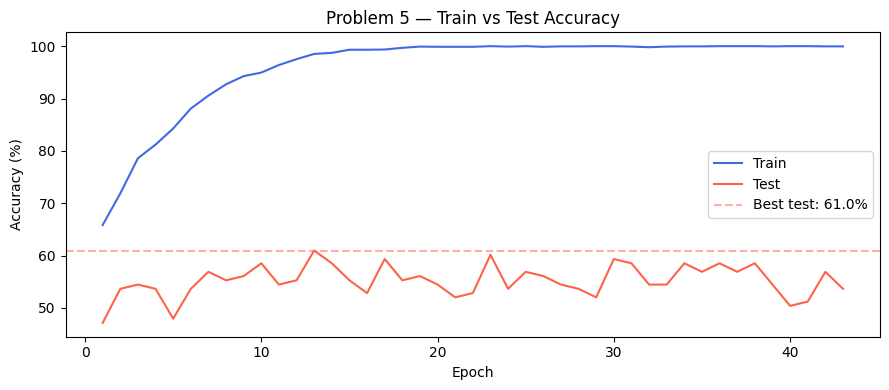

In [8]:
epochs_ran = range(1, len(train_acc_hist) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs_ran, [a*100 for a in train_acc_hist], label="Train", color="royalblue")
plt.plot(epochs_ran, [a*100 for a in test_acc_hist],  label="Test",  color="tomato")
plt.axhline(best_test_acc*100, color="tomato", linestyle="--", alpha=0.5,
            label=f"Best test: {best_test_acc*100:.1f}%")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Problem 5 — Train vs Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 — Final Evaluation on Test Set

Final test accuracy: 53.66%


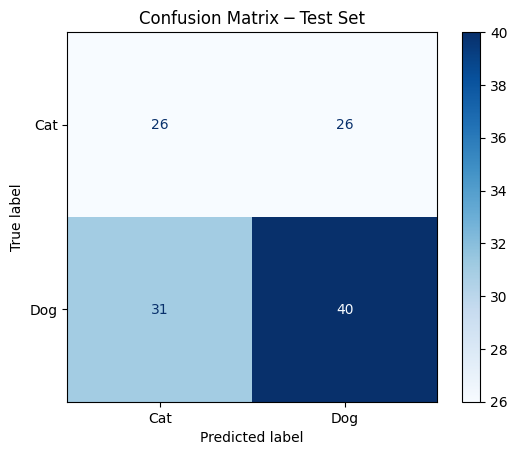

In [9]:
with torch.no_grad():
    Z_test  = my_ANN_5(tX_test, W1,b1,W2,b2,W3,b3,W4,b4,W5,b5, training=False)
    y5_pred = torch.argmax(Z_test, dim=1)
    acc     = torch.mean((y5_pred == ty_test).float())

print(f"Final test accuracy: {acc*100:.2f}%")

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(ty_test.numpy(), y5_pred.numpy())
ConfusionMatrixDisplay(cm, display_labels=["Cat", "Dog"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()